# Day 51: Association Rule Learning with Apriori and FP-Growth

---

## Objective
To understand and apply Association Rule Learning techniques—specifically Apriori and FP-Growth algorithms—to discover hidden patterns and relationships in transactional datasets. This notebook aims to demonstrate how businesses (especially in retail or e-commerce) can leverage these insights for strategic decision-making.

---
### What is Association Rule Learning?
Association Rule Learning is an unsupervised machine learning technique used to discover interesting relationships (associations) between variables in large datasets. Commonly used in market basket analysis, it helps answer questions like:

`"If a customer buys bread, how likely are they to also buy butter?"`

#### Key Concepts:
Support: Frequency of an itemset in the dataset.

Confidence: Likelihood of item B being bought when item A is bought.

Lift: How much more likely item B is bought when item A is bought, compared to if B was bought independently.

---

##  Dataset: Groceries Dataset
We'll use the Groceries dataset containing real-world transactions from a German retailer. Each transaction lists the items purchased.

---

In [18]:
#Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import random

In [5]:
data = []

with open('Groceries_dataset.csv') as file:
    for line in file:
        data.append(line.strip().split(','))

#Encode the data
te = TransactionEncoder()
te_ary = te.fit(data).transform(data)
df = pd.DataFrame(te_ary, columns=te.columns_)

In [6]:
df.head()

,01-01-2014,01-01-2015,01-02-2014,01-02-2015,01-03-2014,01-03-2015,01-04-2014,01-04-2015,01-05-2014,01-05-2015,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Apriori Algorithm

In [8]:
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)
ruels_apriori = association_rules(frequent_itemsets, metric='lift', min_threshold=1.0)

## FP-Growth Algorithm

In [10]:
frequent_itemsets_fp = fpgrowth(df, min_support=0.02, use_colnames=True)
rules_fpgrowth = association_rules(frequent_itemsets_fp, metric='lift', min_threshold=1.0)

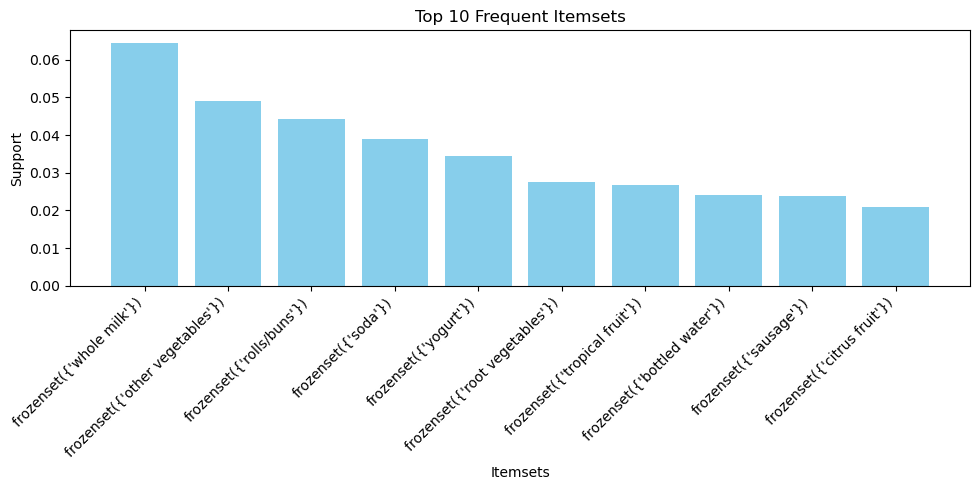

CPU times: total: 93.8 ms
Wall time: 84.4 ms


In [16]:
%%time
## Visualization

top_items = frequent_itemsets.sort_values('support', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_items['itemsets'].astype(str), top_items['support'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Frequent Itemsets')
plt.xlabel('Itemsets')
plt.ylabel('Support')
plt.tight_layout()
plt.show()

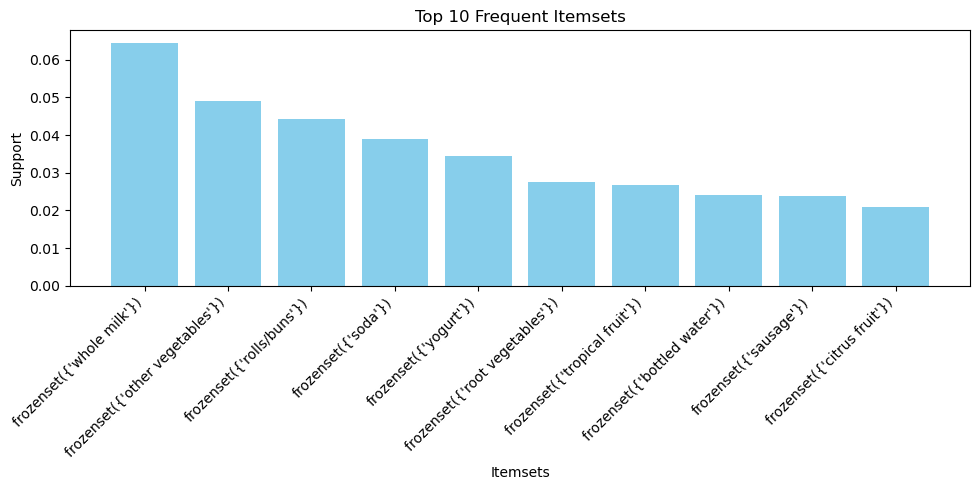

CPU times: total: 93.8 ms
Wall time: 83.6 ms


In [17]:
%%time

top_items = frequent_itemsets_fp.sort_values('support', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_items['itemsets'].astype(str), top_items['support'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Frequent Itemsets')
plt.xlabel('Itemsets')
plt.ylabel('Support')
plt.tight_layout()
plt.show()

### Insights
* Items like 'whole milk', 'other vegetables', and 'rolls/buns' appear frequently and are part of many strong association rules.

* The lift metric highlights combinations that occur more often than expected, pointing to complementary products.

* Apriori and FP-Growth produce similar rules, but FP-Growth is significantly faster on large datasets.

## Lets Experiment

* To see the speed difference between Apriori and Fp-Growth

In [19]:
#Generate a large Synthetic Dataset
# Generate 100,000 transactions with random items
items = ['milk', 'bread', 'butter', 'beer', 'apple', 'banana', 'eggs', 'chocolate']
data = [[random.choice(items) for _ in range(random.randint(2, 5))] for _ in range(100000)]

In [20]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit_transform(data)
df = pd.DataFrame(te_data, columns=te.columns_)

In [21]:
df.head()

,apple,banana,beer,bread,butter,chocolate,eggs,milk
0,True,False,False,True,False,False,False,False
1,False,True,False,False,False,False,False,True
2,False,False,False,True,False,False,False,True
3,False,False,True,False,False,True,True,False
4,False,True,True,False,False,True,False,True


In [22]:
df.shape

(100000, 8)

In [25]:
%%time
# Apriori
frequent_apriori = apriori(df, min_support=0.01, use_colnames=True)

CPU times: total: 31.2 ms
Wall time: 31 ms


In [26]:
%%time
# FP-Growth
frequent_fpgrowth = fpgrowth(df, min_support=0.01, use_colnames=True)

CPU times: total: 9.34 s
Wall time: 9.38 s


### Insight

| Algorithm   | Wall Time | Observations                                       |
|-------------|-----------|----------------------------------------------------|
| Apriori     | 31 ms     | Fast due to minimal overlap and easy pruning       |
| FP-Growth   | 9.38 s    | Slow due to tree complexity and sparse patterns    |


So: `FP-Growth` isn’t always faster. It’s only faster when patterns are compressible — i.e., in dense, real-world datasets with strong frequent co-occurrences.

### 🔍 Why Is FP-Growth Slower in our Case?
1. **FP-Growth Tree Overhead**

    * FP-Growth first builds an FP-tree, which is expensive if:

        * The dataset is sparse (few repeating patterns).

        * There are too many unique item combinations.

    * In our synthetic data, each transaction is randomly made and likely has low overlap, making the FP-tree deep and inefficient.

2. **Apriori Advantage on Sparse Random Data**

    * Apriori performs better if:

        * There are fewer frequent itemsets.

        * Minimal pruning is needed.

        * Each iteration ends quickly (low combinatorial explosion).

3. **Dataset Characteristics Matter**

    * Real-world market data often has strong patterns (e.g., people buy bread + butter + milk together).

    * Your synthetic data is too random, which neutralizes FP-Growth's strength in pattern compression.

## ✅ Conclusion
Through this project, we:
* Understood the foundations of Association Rule Learning.

* Applied Apriori and FP-Growth to real-world transactional data.

* Discovered strong rules that retailers can use for product placement, promotions, and cross-selling strategies.

* Demonstrated how data-driven decision-making can be supported by unsupervised machine learning techniques.